<div class="alert alert-block alert-info">
To open this document and run the code you can directly download the ipynb file from blackboard. 
Also, the pdf version on blackboard.
</div>



# Numerical Solutions of Ordinary Differential Equations


Though this course is mainly concerned with analyzing Ordinary Differential Equations (ODEs) from a theoretical perspective, today we will be talking about *numerical* solutions of ODEs. As you already saw, there are techniques to get explicit solutions to ODEs, but some ODEs which are simple to write do not have an explicit solution. As an example the ODE
$$x'(t) = \sin(t x(t))$$
does not have an analytical solution. However, as we will see, it is quite easy to write a program which yields a (hopefully good) approximation of the solution. 

Let's present the method directly in a generic case. We consider the Cauchy problem 

$$\begin{cases}
x'(t)& = f(t, x(t)), \\
x(0) &= b
\end{cases}$$

(note that we took a starting time of $t=0$ by simplicity) where we assume that we can evaluate the function $f$. 

## The explicit Euler method

We are concerned with this Cauchy problem, and we want to simulate it *forward* in time, that is, approximate $x(t)$ for $t \geq 0$. We already know $x(0) = b$, but then we want to compute what is happening in the future.

We fix a *step-size* $h > 0$. It will be our temporal resolution. Rather than trying to find $x(t)$ for all $t \geq 0$, we will only look for it at $x(n h)$ for $n \in \mathbb{N}$. Then the key idea is to approximate the derivative of $x$ by finite difference. Recall that 
$$x'(t) = \lim_{h \to 0} \frac{x(t+h) - x(t)}{h}.$$
Thus, if $h$ is small enough we expect
$$\frac{x(t+h) - x(t)}{h} \simeq x'(t) = f(t, x(t)).$$
We can reshuffle this equation into

$$\boxed{x(t+h) \simeq  x(t) + h f(t, x(t)). }$$

That is, knowing the value of $x$ at time $t$, we can find an approximation of the value at time $t+h$. 

The basic idea is to iterate this relation. Indeed from $x(0) = b$ we deduce $x(h) \simeq b + f(0, b)$. But then we can continue: $x(2h) \simeq x(h) + f(h, x(h))$, and so on and so forth. This leads to define a sequence $(y_n)_{n \geq 0}$ as follows:

$$\begin{cases}
y_0 & = b, \\
y_{n+1} & =  y_n + h f(nh, y_n),
\end{cases}$$

and we expect $y_n$ to be an approximation of $x(nh)$, with the approximation getting better as $h \to 0$.


### Our first example

Let's illustrate it with an example, the logistic equation:
$$ \begin{cases}
x' & = x(1-x), \\
x(0) & = b
\end{cases}
$$
We get the code below



In [1]:
# First some import 

from math import *
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# Simulation of the logistic equation 

# Parameters

# Initial value
b = 0.1
# Final temporal horizon: run until t <= T
T = 5
# Time step
h = 0.1


# Initialize y and t
y = b
t = 0.
# Instanciate the list in which to store y_n and t
listY = []
listT = []

while t <= T:

    # Store the values
    listY.append(y)
    listT.append(t)
    
    # Iteration of the Euler scheme
    y = y + h * y*(1-y)
    t = t + h
    
    
# Convert the output in numpy array

arrayY = np.array(listY)
arrayT = np.array(listT)


In [3]:
print(listY)


[0.1, 0.10900000000000001, 0.11871190000000001, 0.12917383847983901, 0.14042263427306137, 0.15249304607874892, 0.16541693777638627, 0.17922235522369323, 0.19393252548486978, 0.20956479558926278, 0.22612953479315212, 0.2436290316218906, 0.26205642427917764, 0.28139470975649655, 0.3016158824642519, 0.32268025665520816, 0.3445360275172219, 0.3671191228432093, 0.39035339009181347, 0.4141511521853777, 0.43841414971826786, 0.4630348680227755, 0.4878982259245661, 0.5128835806309888, 0.5378669819660014, 0.56272359113368, 0.5873301662452095, 0.6115675104515679, 0.6353227795127319, 0.6584915540472267, 0.6809795967767962, 0.702704235331847, 0.7235953346297002, 0.7435958472628834, 0.7626619535825112, 0.7807628233965331, 0.7978800470963738, 0.81400679485056, 0.8291467681293279, 0.8433130086323297, 0.8565266264427115, 0.8688155029064494, 0.8802130153880356, 0.8907568216809894, 0.9004877323119665, 0.9094486899387284, 0.9176838669694743, 0.925237885696817, 0.9321551597536271, 0.9384793515434587, 0.944

We can plot the results. We can compare with the analytical solution, in this case

$$x(t) = \frac{b e^t}{1-b + b e^t}.$$

For the comparision, we can for instance compute the maximal value of $|y_n - x(nh)|$, where $y_n$ is given by the Euler scheme.


The maximal error is 0.012795629295983768.


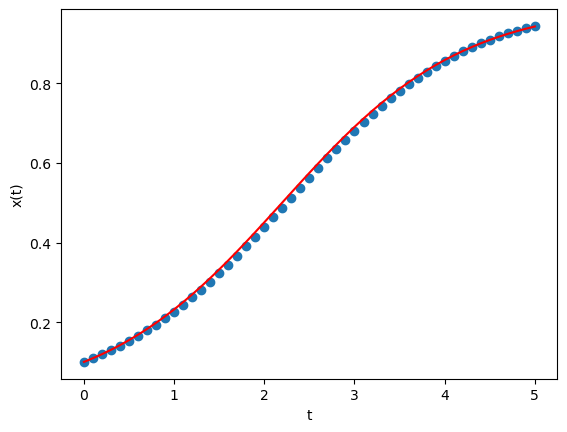

In [4]:
# Plotting the result

# Plotting the output
plt.scatter(arrayT, arrayY)

# Computing and plotting the true solution 
arrayTrueSolution = np.divide( b * np.exp(arrayT), 1 - b + b * np.exp(arrayT) )
plt.plot(arrayT, arrayTrueSolution, color = 'r')

print("The maximal error is " + str(np.max(np.abs(arrayTrueSolution - arrayY))) + ".")

# Legend 
plt.xlabel("t")
plt.ylabel("x(t)")

plt.show()




Let's encapsulate all of this in a python function. 


In [5]:
def explicitEuler(f,t0,b,T,h) :
    """Solve the equation with explicit Euler
    f function of two variables (time and x)
    t0  initial time
    b initial value for x(t0)
    T final temporal horizon
    h temporal step size
    
    Output
    arrayT numpy array with the values of T
    arrayX numpy array with the values of X
    """
    
    # Number of time steps
    N = floor((T - t0)/h + 1)
    
    arrayT = np.zeros(N)
    arrayX = np.zeros(N)
    
    # Initial conditions
    arrayT[0] = t0
    arrayX[0] = b
    
    for i in range(N-1):
        arrayT[i+1] = arrayT[i] + h
        arrayX[i+1] = arrayX[i] + h * f(arrayT[i], arrayX[i])
        
    return arrayT, arrayX
    

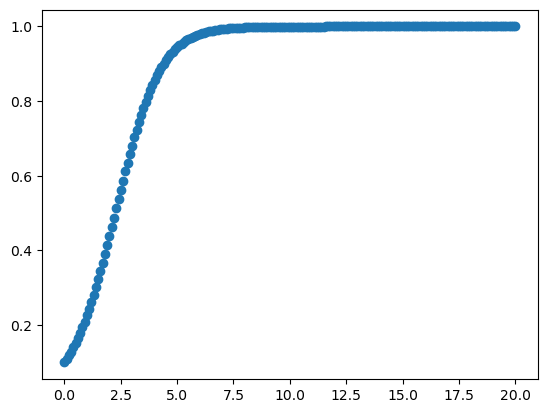

In [6]:
# Test with the logistic equation

def fLogistic(t,x):
    return x*(1.-x)

arrayT, arrayX = explicitEuler(fLogistic,0,0.1,20,0.1)

plt.scatter(arrayT, arrayX)
plt.show()

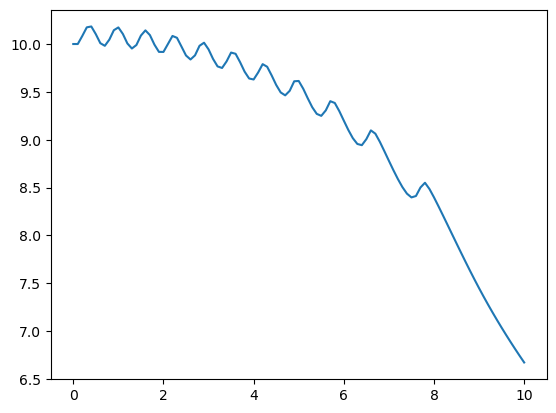

In [7]:
# Test with the equation x' = sin(tx) for which no explicit formula exists

def fUnsolvable(t,x):
    return sin(t*x)

# Temporal horizon
T = 10
# Initial condition
b = 10.

arrayT, arrayX = explicitEuler(fUnsolvable,0,b,T,0.1)

plt.plot(arrayT, arrayX)
plt.show()

### An interesting case: blow up in finite time

Let's look at 
$$ \begin{cases}
x' & = x^2, \\
x(0) & = 1
\end{cases}
$$
whose explicit solution is $x(t) = 1/(1-t)$, it is only defined for $t < 1$. 


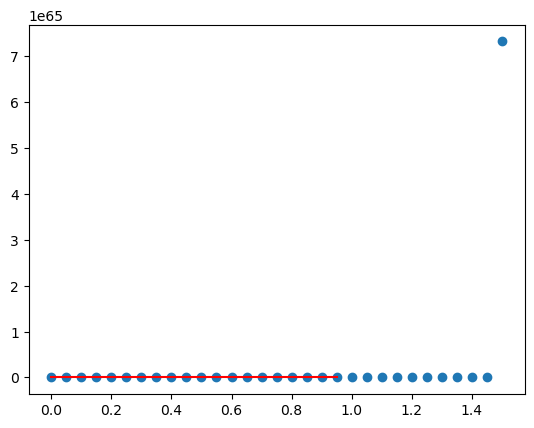

In [8]:
# What happens in case of blow up

def fBlowUp(t,x):
    return x**2

# Final time
T = 1.5
# Step size
h = 0.05

arrayT, arrayX = explicitEuler(fBlowUp,0,1,T,h)

# Comparing with the explicit solution 
# See where the blow up is
indexMax = np.argmax(arrayT >= 1. - 0.001)
if indexMax == 0:
    indexMax = len(arrayT)
# Compute the exact solution up to the blow up
arrayXExact = np.maximum( 0., np.divide(1,1 - arrayT[:indexMax])  )


plt.scatter(arrayT, arrayX)
plt.plot(arrayT[:indexMax], arrayXExact, color = 'r')
plt.show()

### An example of an empirical study of an ODE

Let's look at 
$$
\begin{cases}
x'(t) & = x^2(t) - t, \\
x(0) & = b
\end{cases}
$$

Studying it numerically, we can clearly distinguish two behaviors depending on the value of $b$. If $b < b^* \simeq 0.728$, then there is asymptotic convergence to a solution tending to $- \infty$, if $b > b^*$ there seems to be blow up in finite time. 


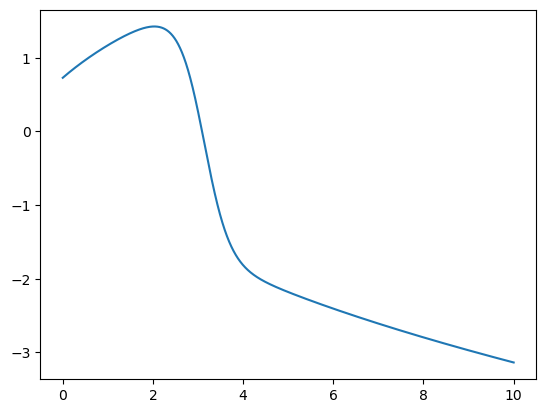

In [9]:
# Distinguishing empirically between two behaviors

def fEmpirical(t,x):
    return x**2 - t

b = 0.728

arrayT, arrayX = explicitEuler(fEmpirical,0,b,10,0.001)


plt.plot(arrayT, arrayX)
plt.show()

### Theoretical guarantees

We mention the following result which is not so easy to prove and which belongs to the realm of numerical analysis.

**Theorem** *Take $f$ is a $C^1$ function over an open set $U \subset \mathbb{R} \times \mathbb{R}$ and valued in $\mathbb{R}$. Assume that the Cauchy problem*

$$\begin{cases}
x'(t) &= f(t,x(t)), \\
x(0) &=b
\end{cases}$$

*has a unique solution $x(t)$ for $t \in [0,T]$ with $(t,x(t)) \in U$ for all $t \in [0,T]$. For $h > 0$, define a sequence $(y^{(h)}_n)_{n \geq 0}$ following the Euler scheme, that is:*

$$\begin{cases}
y^{(h)}_0 &= b, \\
y^{(h)}_{n+1} &=  y^{(h)}_n + h f(nh, y^{(h)}_n),
\end{cases}$$

*as long as $nh \leq T$.*

*Then we can conclude*
$$ \lim_{h \to 0} \left( \sup_{\{ n \ : \ nh \leq T \}} | y^{(h)}_n - x(nh)  | \right) = 0 $$

This result says that errors do not snowball in an uncontrolled way and that, for a fixed time horizon, we indeed recover the solution given by the theory. 

However it does not mean that the explicit Euler method is the end of the game.
 * One may be required to take $h$ so small that computations become too long. We can try to quantify the speed at which the convergence occur, and design methods which converge faster to the true solutions. 
 * One may want to study the long time behavior. For instance, in the case of the logistic equation: is it true that our discrete solutions converge to $1$ if we start from an initial condition in $(0,1]$? If we observe a blow-up in finite time, or even a divergence, is it really what happens for the equation, or an artifact of the discretization?


## Higher order methods


For this discussion, to simplify the notations we concentrate on autonomous systems $x'(t) = f(x(t))$, that is, $f$ does not depend on $t$. However, what is written below can be extended to the case $f = f(t,x)$.

If we look at the approximation we used to define the Euler method: $x(t+h) \simeq  x(t) + h f(x(t))$, we see that it bloils down to a Taylor expansion of order $1$: namely, assuming that $f$ is of class $C^2$.

$$x(t+h) = x(t) + h x'(t) + O(h^2). $$

Thus the so-called *local truncation error* is of order $h^2$. However, the *global* error is usally of order $h$ because the local errors accumulate: we have typically $T/h$ time steps, each with an error of $h^2$, eventually creating an error of $h$. That is, by dividing $h$ by $2$, we expect at most the global error to be divided by $2$. There are many methods to decrease the truncation error ([Runge-Kutta](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods), [Adams–Bashforth](https://en.wikipedia.org/wiki/Linear_multistep_method), etc.). We will present here only one, namely the Adams-Bashforth of order $2$. 

### The Adams–Bashforth scheme

We start with our expansion on top, but we push one more order:

$$x(t+h) = x(t) + h x'(t) + \frac{h^2}{2} x''(t) + O(h^3). $$

Next we already know that $x'(t) = f(x(t))$, and for $x''(t)$ we use a finite difference formula:

$$ x''(t) = [f(x(t))]' \simeq \frac{f(x(t)) - f(x(t-h))}{h}, $$

where here we go backward in time to keep an explicit scheme. Thus plugging back in the Taylor expansion of $x$ we obtain 

$$x(t+h) = x(t) + h f(x(t)) + \frac{h^2}{2} \left( \frac{f(x(t)) - f(x(t-h))}{h} + O(h) \right) + O(h^3), $$

which after simplifications become

$$\boxed{x(t+h) = x(t) + \frac{3h}{2}  f(x(t)) - \frac{h}{2}  f(x(t-h)) + O(h^3).} $$

Now the local error is of order $3$, thus we expect the global error to be of order $2$: dividing $h$ by $2$, we expect at most the global error to be divided by $4$. Note however that now we need the two previous values $x(t)$ and $x(t-h)$ to compute $x(t+h)$. This leads to define the following sequence $(y_n)_{n \geq 0}$:

$$\begin{cases}
\text{Initialize } y_0, y_1  \\
y_{n+1} =  y_n + \frac{3h}{2} f(y_n) - \frac{h}{2} f(y_{n-1}),
\end{cases}$$

and we expect $y_n$ to be an approximation of $x(nh)$, better than the one given by explicit Euler. Here to initialize $y_0, y_1$ we proceed as follows: of course $y_0 = b$, and for $y_1$ we use the explicit Euler scheme, that is, $y_1 = y_0 + h f(y_0)$.


In [10]:
# We encapsulate the AB scheme in a function

def AdamsBashforth(f,t0,b,T,h) :
    """Solve the equation with Adams Bashforth
    f function of one variable (x)
    t0  initial time
    b initial value for x(t0)
    T final temporal horizon
    h temporal step size
    
    Output
    arrayT numpy array with the values of T
    arrayX numpy array with the values of X
    """
    
    # Number of time steps
    N = floor((T - t0)/h + 1)
    
    arrayT = np.zeros(N)
    arrayX = np.zeros(N)
    
    # Initialization. Now we need to initalize the first two steps
    # Initial conditions
    arrayT[0] = t0
    arrayX[0] = b
    # At time t0+h: we use an explicit Euler scheme for x 
    arrayT[1] = t0+h
    arrayX[1] = arrayX[0] + h*f(arrayX[0])
    
    # Main loop with the recursive recurrence relation
    for i in range(1,N-1):
        arrayT[i+1] = arrayT[i] + h
        arrayX[i+1] = arrayX[i] + 1.5*h*f(arrayX[i]) -0.5*h*f(arrayX[i-1])
        
    return arrayT, arrayX

The maximal error is 0.0009615735591319563.


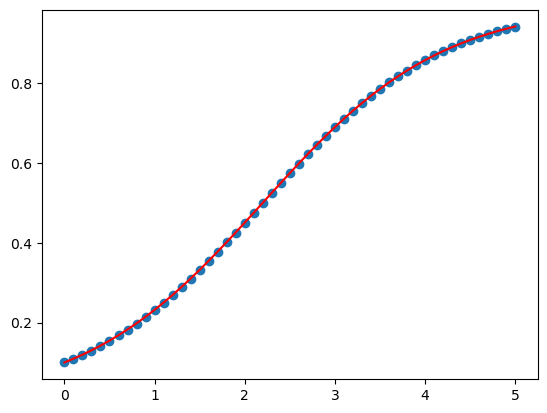

In [11]:
# Let's illustrate this on the logistic equation 

# Redefine flogistic to be independent of t
def fLogisticAutonomous(x):
    return x*(1-x)

# Initial value
b = 0.1
# Final temporal horizon
T = 5
# Time step
h = 0.1

arrayABT,arrayABX = AdamsBashforth(fLogisticAutonomous,0.,b,T,h)

# Function to compute the explicit solutuion

def solutionLogistic(t) :
    return np.divide( b * np.exp(t), 1 - b + b * np.exp(t) )    
    
    
# Compute the global error    
print("The maximal error is " + str(np.max(np.abs(solutionLogistic(arrayABT) - arrayABX))) + ".")    


plt.scatter(arrayABT, arrayABX)
plt.plot(arrayABT,solutionLogistic(arrayABT), color = 'r')
plt.show()    

### Convergence plot

To illustrate the difference between the two methods, we show how the error depends on $h$. Specifically we plot the error between the approximate and exact solution as a function of $h$.

In [ ]:
# Function which computes the error for the two schemes 
# For simplicity we restrict to the logistic equation.

def computeErrors(t0,b,T,h):
    
    # Compute the solutions
    arrayT,arrayX = explicitEuler(fLogistic,t0,b,T,h)
    arrayABT,arrayABX = AdamsBashforth(fLogisticAutonomous,0.,b,T,h)
    
    # Compute the errors 
    errorE = np.max(np.abs(solutionLogistic(arrayT) - arrayX))
    errorAB = np.max(np.abs(solutionLogistic(arrayABT) - arrayABX))
    
    return errorE, errorAB

# Then run a loop where we compute the error for several values of h.

# Parameters 

# Initial condition 
t0 = 0.
b = 0.1
# Final time
T = 5.

# Number of values of h tested
N = 35

# Create an array of values of h, that we space exponentially 
# We use an exponential spacing because it renders better on the log-log plot.
arrayH = np.logspace(-N+1, 0, base=1.5, num =N)

# Create an array for the errors 
arrayErrorE = np.zeros(N)
arrayErrorAB = np.zeros(N)

# Compute the errors
for i in range(N):
    arrayErrorE[i], arrayErrorAB[i] = computeErrors(t0,b,T,arrayH[i])
    
# Plot the errors 
plt.plot(arrayH,arrayErrorE, color = 'r', marker='o', label = "Euler")
plt.plot(arrayH,arrayErrorAB, color = 'b', marker='o', label = "AB")

# Put the legend
plt.xlabel("time step h")
plt.ylabel("error")
plt.legend()
plt.show()


We don't see much in this graph. The problem is that the small values of $h$ are the most important. To see better we plot the same quantities, but in a log log scale: we plot the log of the error as a function of $\log 1/h$. And we see clearly how the error of Adams-Bashforth is much smaller as $h \to 0$.

In [ ]:
# Plot the errors 
plt.loglog(np.reciprocal(arrayH),arrayErrorE, color = 'r', marker='o', label = "Euler")
plt.loglog(np.reciprocal(arrayH),arrayErrorAB, color = 'b', marker='o', label = "AB")

# Put the legend
plt.xlabel("Inverse time step 1/h")
plt.ylabel("error")
plt.legend()
plt.show()

## Stability issues and the implicit Euler method

### Stability issues

To discuss stability, let us consider one of the simplest ODE, the Malthus equation
$$x' = - r x$$
where $r > 0$. The solution is $x(t) = x(0) \exp(- rt)$: a smooth and fast decay towards $0$. 


In [ ]:
# Explicit Euler with an exponential decay
# We take an initial condition of x(0) = 1

r = 1.
h = 3.

def fExp(t,x):
    return -r*x

arrayT, arrayX = explicitEuler(fExp,0,1,20,h)

# Comparing with the explicit solution 
arrayXExact = np.exp(- r*arrayT)


plt.scatter(arrayT, arrayX)
plt.plot(arrayT, arrayXExact, color = 'r')
plt.show()

To understand what is happenning, let us write explicitly the iterate of the discrete sequence. In this case, for some $h > 0$ it reads
$$\begin{cases}
y_0 & = 1, \\
y_{n+1} & = y_n - rh y_n = (1-rh) y_n
\end{cases}$$
which gives us a geometric sequence. The solution here is given by 
$$y_n = (1-rh)^n$$

**As a consequence, the sequence $(y_n)_{n \geq 1}$ diverges if $|1-rh| > 1$ while it converges if $|1-rh| < 1$**. In particular, in the case $r > 0$, it means that if $h > 2/r$ (that is, $h$ is not small enough), then the asymptotic behavior of the sequence $(y_n)_{n \geq 1}$ differs drastically from the one of the solution $x(t)$. 




###  The implict Euler method

When we derived the explicit Euler method, we relied on 

$$x'(t) \simeq \frac{x(t+h) - x(t)}{h}.$$

However, note that it also work "the other way around", that is, 

$$x'(t) \simeq \frac{x(t) - x(t-h)}{h}.$$

Using again that $x'(t) = f(t,x(t))$ is given by the equation, we reshuffle to write 

$$x(t) \simeq  x(t-h) + h f(t, x(t)) $$

and, doing the subsitution $t$ into $t+h$, we find

$$\boxed{x(t+h) \simeq  x(t) + h f(t+h, x(t+h))}.$$

This is almost like the explicit Euler method, except now $x(t+h)$ is also on the other side. So at every step, one needs to solve an equation to find $x(t+h)$. Specifcally, the method reads: find a sequence $(y_n)_{n \geq 0}$ satisfying:

$$\begin{cases}
y_0 & = b, \\
y_{n+1} & =  y_n + h f((n+1)h, y_{n+1}),
\end{cases}$$

and we expect $y_n$ to be an approximation of $x(nh)$, with the approximation getting better as $h \to 0$. The caveat is that at each iteration on needs to solve an equation, for which there may be no analytical solutions. However, it may be possible to use some numerical method so solve approximatively this equation. 

Why go through all this additional trouble? Because generically an implicit Euler method is much more stable than the explicit one. 




###  Example on our exponential decay

Let's work through our equation $x' = - rx$. Now the implicit Euler method reads

$$\begin{cases}
y_0 & = 1, \\
y_{n+1} & = y_n - rh y_{n+1}, 
\end{cases}$$

and the second equation yields $y_{n+1} = y_n/(1+rh)$, thus

$$y_n = \frac{1}{(1+rh)^n}.$$

**As a consequence, for any $h,r > 0$ the sequence $(y_n)_{n \geq 0}$ converges to $0$.**



In [ ]:
# Simulation of the exponential equation via implicit Euler

# Parameters

# Parameter r
r = 1.
# Final temporal horizon: run until t <= T
T = 20
# Time step
h = 3

# Total number of steps
N = floor(T/h + 1)

arrayT = np.linspace(0, (N-1)*h ,N)
# Here for simplicity I use directly the formula derived theoretically for the solution of implicit Euler
arrayY = np.power( 1/(1+r*h), np.arange(N) )
# Also the explicit solution 
arrayXExact = np.exp(- r*arrayT)



In [ ]:
# Plotting of the solutions 

plt.scatter(arrayT, arrayY)
plt.plot(arrayT, arrayXExact, color = 'r')
plt.show()

###  Stability of the Adams-Bashforth scheme for the exponential decay

Assume that for 

$$f(x) = - rx$$

with some $r > 0$ we use the Adams-Bashforth scheme of order $2$. That leads to the recurrence 

$$
y_{n+1} = \Big(1 - \frac{3rh}{2} \Big) y_n + \frac{rh}{2} y_{n-1}.
$$

To solve this recurrence we use the ansatz $y_n = \lambda^n$ for some $\lambda \in \mathbb{R}$. Such a sequence is a solution if and only if $\lambda$ solves

$$
\lambda^2 - \Big(1 - \frac{3rh}{2}\Big) \lambda - \frac{rh}{2} = 0. 
$$

The discrimant is always positive, we have to real-valued solutions $\lambda_- \leq \lambda_+$

$$
\lambda_- = \frac{1}{2} \Big(1 - \frac{3rh}{2}\Big) - \frac{1}{2} \sqrt{ \Big(1 - \frac{3rh}{2}\Big)^2 + 2 rh }, \qquad \lambda_+ = \frac{1}{2} \Big(1 - \frac{3rh}{2}\Big) + \frac{1}{2} \sqrt{ \Big(1 - \frac{3rh}{2}\Big)^2 + 2 rh }.
$$

The general solution is a linear combination of these two solutions, of the form $y_n = a \lambda_-^n + b \lambda_+^n$. Thus we have convergence to zero for any initial condition if and only if $|\lambda_-| < 1$ and $|\lambda_+| < 1$. Given $\lambda_- \leq \lambda_+$, we have it if $-1 < \lambda_- < \lambda_+ < 1$. The condition $\lambda_+ < 1$ always holds if $r, h > 0$. Indeed, it holds if 

$$
\frac{1}{2} \Big(1 - \frac{3rh}{2}\Big) + \frac{1}{2} \sqrt{ \Big(1 - \frac{3rh}{2}\Big)^2 + 2 rh } < 1,
$$

which can be reshuffled 

$$
\sqrt{ \Big(1 - \frac{3rh}{2}\Big)^2 + 2 rh } < 1 + \frac{3rh}{2}.
$$

Squaring, expanding the square this is equivalent to 

$$
2 rh < \Big(1 + \frac{3rh}{2}\Big)^2 - \Big(1 - \frac{3rh}{2}\Big)^2 = 6rh,
$$
which is always true. On the other hand the condition $\lambda_- > -1$ is satisfied if 

$$
\frac{1}{2} \Big(1 - \frac{3rh}{2}\Big) - \frac{1}{2} \sqrt{ \Big(1 - \frac{3rh}{2}\Big)^2 + 2 rh } > -1,
$$

which can be re-ordered

$$
\sqrt{ \Big(1 - \frac{3rh}{2}\Big)^2 + 2 rh } <  3 \Big(1 - \frac{rh}{2}\Big). 
$$

Squaring and simplifying, it is equivalent to 

$$
rh < 1.
$$

**As a consequence, the sequence $(y_n)_{n \geq 0}$ converges to $0$ if and only if $h < 1/r$.** Comparing, the condition in the case of the explicit Euler method was $h < 2/r$. So the Adam-Bashforth scheme tends to be more unstable than the explicit Euler one. This is a general rule of thumb: for explicit methods, the higher order the scheme is, the more unstable it becomes. 



